# T8 · Train your own tiny transformer

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/gkiri/tiny_repo/blob/main/tiny-transformer/notebooks/T8-train-your-own.ipynb)

Train **our tiny transformer** yourself: 9,417 numbers that learn to write like Shakespeare, with the course's own recipe.

**To run it:** choose **Runtime → Run all**, or press ▶ on each cell from top to bottom. No GPU is needed.

| | Quick run (the default) | Full run (`QUICK = False` in section 7) |
|---|---|---|
| Steps | 5,000 | 100,000, the course's run |
| Time on the course's server (CPU) | about 1 minute | about 21 minutes |
| Held-back loss | about 2.02 | about 1.93 |

Your computer's times and numbers will differ a little.
The data and this notebook come from the course's public repository, [gkiri/tiny_repo](https://github.com/gkiri/tiny_repo).

## 1 · Set up

Install the libraries (Colab already has them), then choose where to compute: a GPU if there is one, otherwise the CPU.

In [1]:
%pip install -q -r https://raw.githubusercontent.com/gkiri/tiny_repo/main/tiny-transformer/requirements.txt
# in Colab, ignore any note about restarting: these libraries are already there

Note: you may need to restart the kernel to use updated packages.


In [2]:
import copy, json, math, os, shutil, sys, time, urllib.request

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F

REPO = "https://raw.githubusercontent.com/gkiri/tiny_repo/main/tiny-transformer/"   # the course's files


def download(name):
    """Read a text file from the course's repository on GitHub."""
    with urllib.request.urlopen(REPO + name) as response:
        return response.read().decode("utf-8")


torch.set_num_threads(1)                                   # this tiny model trains fastest on one thread
device = "cuda" if torch.cuda.is_available() else "cpu"   # a GPU if there is one, otherwise the CPU
print("PyTorch", torch.__version__, "· computing on", device)

PyTorch 2.10.0+cpu · computing on cpu


## 2 · Get the data

**Tiny Shakespeare:** lines from Shakespeare's plays, in one text file.

In [3]:
text = download("data/tinyshakespeare.txt")
print(f"{len(text):,} characters\n")
print(text[:200])

1,115,394 characters

First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you


## 3 · Characters become numbers

The model works with numbers, so each different character gets an id. The last 10% of the text is **held back**: the model
never trains on it, so it shows how well the model does on text it has not seen.

In [4]:
chars = sorted(set(text))        # every different character, in order
vocab_size = len(chars)          # 65

char_to_id = {}
for i, ch in enumerate(chars):
    char_to_id[ch] = i


def encode(s):
    return [char_to_id[ch] for ch in s]      # characters → ids


def decode(ids):
    return "".join([chars[i] for i in ids])  # ids → characters


print(vocab_size, "characters:", repr("".join(chars)))
print(repr(text[:13]), "→", encode(text[:13]))

65 characters: "\n !$&',-.3:;?ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz"
'First Citizen' → [18, 47, 56, 57, 58, 1, 15, 47, 58, 47, 64, 43, 52]


In [5]:
ids = torch.tensor(encode(text))     # the whole text as ids
n_train = int(0.9 * len(ids))
train_ids = ids[:n_train]            # the first 90%: the model learns from this
held_back_ids = ids[n_train:]        # the last 10%: only for checking

print(f"training text: {len(train_ids):,} characters · held back: {len(held_back_ids):,} characters")

training text: 1,003,854 characters · held back: 111,540 characters


## 4 · Training examples

One example is a window of 32 characters, `x`, and the same window shifted one place to the right, `y`. At every place, `y`
holds the right next character, so one window asks 32 questions. A batch is 64 windows.

In [6]:
context_length = 32    # characters the model reads at once
batch_size = 64        # windows per training step


def random_starts(data, how_many):
    """Random places to start a window (each window and its target fit inside the text)."""
    return torch.randint(len(data) - context_length - 1, (how_many,))


def make_windows(data, starts):
    """x: the window at each start · y: the same window shifted one character to the right."""
    x = torch.stack([data[s : s + context_length] for s in starts])
    y = torch.stack([data[s + 1 : s + context_length + 1] for s in starts])
    return x.to(device), y.to(device)


x, y = make_windows(train_ids, random_starts(train_ids, batch_size))
print("x:", tuple(x.shape), "· y:", tuple(y.shape), "  (windows, characters)\n")
print("x[0]:", repr(decode(x[0].tolist())))
print("y[0]:", repr(decode(y[0].tolist())))

x: (64, 32) · y: (64, 32)   (windows, characters)

x[0]: 'our liberties:\nMarcius would hav'
y[0]: 'ur liberties:\nMarcius would have'


## 5 · The model

```
ids ─► character table + place table ─► block: attention, then feed-forward ─► final norm ─► 65 scores
       what, and where                   look back     think                                one per next character
```

Four small parts. Each character becomes a row of 28 numbers, and every part works on those rows. The comments explain each
PyTorch piece the first time it appears.

In [7]:
embed_size = 28                         # numbers in each character's row
num_heads = 2                           # attention heads
head_size = embed_size // num_heads     # 14 numbers per head
hidden_size = 56                        # the feed-forward's wider middle

In [8]:
class Attention(nn.Module):              # nn.Module: a PyTorch part with learned numbers inside
    """Each character looks back at the earlier ones and collects what it needs."""

    def __init__(self):                  # __init__ builds the part ("self" is the part itself)
        super().__init__()               # let PyTorch set the part up first
        # nn.Linear: a learned table of weights (28 × 28) plus a bias; it turns each row into a new row
        self.query = nn.Linear(embed_size, embed_size)   # what each character is looking for
        self.key = nn.Linear(embed_size, embed_size)     # what each character offers
        self.value = nn.Linear(embed_size, embed_size)   # what each character passes on
        self.mix = nn.Linear(embed_size, embed_size)     # combines the heads' findings

    def forward(self, x):                # forward runs when the part is called: attention(x)
        n = x.shape[1]                   # x: (windows, characters, 28), so n = characters per window
        q = self.query(x)                # (windows, characters, 28)
        k = self.key(x)
        v = self.value(x)
        ones = torch.ones(n, n, device=x.device)
        later = torch.triu(ones, diagonal=1) == 1         # True above the diagonal: the later characters

        heads = []
        for h in range(num_heads):                       # each head uses its own 14 of the 28 numbers
            start = h * head_size
            end = start + head_size
            qh = q[:, :, start:end]                      # (windows, characters, 14)
            kh = k[:, :, start:end]
            vh = v[:, :, start:end]
            kh_turned = kh.transpose(1, 2)               # swap the last two axes: (windows, 14, characters)
            scores = qh @ kh_turned                      # @ multiplies matrices: every query · every key
            scores = scores / math.sqrt(head_size)       # keep the scores small
            scores = scores.masked_fill(later, float("-inf"))   # -inf for later characters: probability 0
            weights = F.softmax(scores, dim=-1)          # along the last axis: shares that add up to 1
            heads.append(weights @ vh)                   # a weighted mix of the values: (windows, characters, 14)
        both = torch.cat(heads, dim=-1)                  # the heads side by side: (windows, characters, 28)
        return self.mix(both)

In [9]:
class FeedForward(nn.Module):
    """Each character's row on its own: widen, bend, narrow."""

    def __init__(self):
        super().__init__()
        self.grow = nn.Linear(embed_size, hidden_size)      # 28 → 56
        self.shrink = nn.Linear(hidden_size, embed_size)    # 56 → 28

    def forward(self, x):
        x = self.grow(x)
        x = F.gelu(x)               # GELU bends the numbers: big ones pass, negative ones shrink towards 0
        return self.shrink(x)


class Block(nn.Module):
    """Look back (attention), then think (feed-forward); each result is added to the row."""

    def __init__(self):
        super().__init__()
        self.norm1 = nn.LayerNorm(embed_size)     # LayerNorm: rescales each row to a steady size
        self.attention = Attention()
        self.norm2 = nn.LayerNorm(embed_size)
        self.feed_forward = FeedForward()

    def forward(self, x):
        x = x + self.attention(self.norm1(x))     # look back, and add what was found
        x = x + self.feed_forward(self.norm2(x))  # think, and add that too
        return x

In [10]:
class TinyTransformer(nn.Module):
    def __init__(self):
        super().__init__()
        # nn.Embedding: a table with one learned row per id
        self.char_table = nn.Embedding(vocab_size, embed_size)       # a row for each character
        self.place_table = nn.Embedding(context_length, embed_size)  # a row for each place 0 … 31
        self.block = Block()
        self.final_norm = nn.LayerNorm(embed_size)
        self.readout_bias = nn.Parameter(torch.zeros(vocab_size))   # nn.Parameter: learned numbers, one per character

        # start with small random numbers (biases at 0), so the first guesses are nearly even
        for part in self.modules():                                 # visit every part, inside parts too
            if isinstance(part, (nn.Linear, nn.Embedding)):
                nn.init.normal_(part.weight, std=0.02)              # random numbers around 0
            if isinstance(part, nn.Linear):
                nn.init.zeros_(part.bias)

    def forward(self, ids):                                         # ids: (windows, characters)
        places = torch.arange(ids.shape[1], device=ids.device)      # 0, 1, 2, …
        x = self.char_table(ids) + self.place_table(places)         # what + where: (windows, characters, 28)
        x = self.block(x)                                           # look back, then think
        x = self.final_norm(x)
        table = self.char_table.weight                              # reuse the character table: (65, 28)
        scores = x @ table.T + self.readout_bias                    # .T turns it to (28, 65): a score per character
        return scores                                               # (windows, characters, 65)

## 6 · Before training

The model starts with small random numbers, so it knows nothing yet. The **loss** measures its surprise at the right next
character: guessing evenly among 65 characters gives ln 65 ≈ 4.17. `write` lets it write, one character at a time.

In [11]:
torch.manual_seed(1337)              # a seed fixes the random numbers, so every run starts the same
model = TinyTransformer().to(device)


def count(part):
    """How many learned numbers a part has."""
    total = 0
    for numbers in part.parameters():
        total += numbers.numel()
    return total


print("character table ", count(model.char_table))
print("place table     ", count(model.place_table))
print("block           ", count(model.block))
print("final norm      ", count(model.final_norm))
print("readout bias    ", model.readout_bias.numel())
print(f"total            {count(model):,} learned numbers")

character table  1820
place table      896
block            6580
final norm       56
readout bias     65
total            9,417 learned numbers


In [12]:
def loss_of(scores, y):
    """Cross-entropy: how surprised the model is by the right next characters (lower is better)."""
    flat_scores = scores.reshape(-1, vocab_size)   # one row of 65 scores per question (-1: work out how many)
    flat_targets = y.reshape(-1)                   # the right answer to each question
    return F.cross_entropy(flat_scores, flat_targets)


def write(model, prompt, length, temperature=1.0, seed=0):
    """Continue the prompt one character at a time.
    temperature: below 1 is safer, above 1 is wilder · seed: the same seed writes the same text."""
    torch.manual_seed(seed)
    ids = encode(prompt)
    for _ in range(length):
        window = torch.tensor([ids[-context_length:]], device=device)   # the last 32 characters
        with torch.no_grad():                                   # only predicting: no gradients needed
            scores = model(window)[0, -1]                       # the first window, its last place: 65 scores
        probabilities = F.softmax(scores / temperature, dim=-1)
        next_id = torch.multinomial(probabilities, 1).item()    # draw one character
        ids.append(next_id)
    return decode(ids)


x, y = make_windows(held_back_ids, random_starts(held_back_ids, batch_size))
with torch.no_grad():
    loss = loss_of(model(x), y)
print(f"untrained loss {loss.item():.2f} · an even guess: ln {vocab_size} = {math.log(vocab_size):.2f}\n")
print(write(model, "ROMEO:\n", 100))

untrained loss 4.18 · an even guess: ln 65 = 4.17



ROMEO:
t3ZrjmhPkqkARxLsXltUWRoHcu ?exhkyU&aNdkIgAlsvSBUMycoRD$BygX-fntw
kVrM z&?j DJR!sOEHelC!BTg3xUhPRCs3M


## 7 · The recipe

The course's recipe: the AdamW optimizer, and a learning rate that rises for 200 steps, then glides down along a cosine curve.
Every 500 steps, a **check** measures the loss and accuracy on the same fixed windows, so two checks differ only because the
model changed. After 20 checks without progress, training stops.

In [13]:
QUICK = True        # True: the first 5,000 steps (about a minute) · False: the course's full 100,000 steps
if QUICK:
    steps = 5_000
else:
    steps = 100_000

peak_lr = 0.003         # the highest learning rate
final_lr = 0.0003       # the learning rate at the very end
warmup_steps = 200      # steps to rise from 0 to the peak
total_steps = 100_000   # the course's whole schedule (the quick run is its start)
check_every = 500       # steps between checks
patience = 20           # stop after this many checks without progress


def learning_rate(step):
    if step < warmup_steps:                                       # rise in a straight line
        return peak_lr * step / warmup_steps
    progress = (step - warmup_steps) / (total_steps - warmup_steps)   # 0 → 1
    return final_lr + 0.5 * (peak_lr - final_lr) * (1 + math.cos(math.pi * progress))   # glide down

In [14]:
torch.manual_seed(2024)                                        # the same check windows every time
train_check = random_starts(train_ids, 6_400)                  # 6,400 windows of training text
held_back_check = random_starts(held_back_ids, 6_400)          # 6,400 windows of held-back text


def check(model, data, starts):
    """The loss and accuracy on the given windows."""
    with torch.no_grad():                                      # only measuring, so no gradients
        x, y = make_windows(data, starts)
        scores = model(x)
        loss = loss_of(scores, y)
        guesses = scores.argmax(dim=-1)                        # the top-scoring character at each place
        right = (guesses == y).float()                         # 1 where the guess is right, 0 where wrong
        accuracy = right.mean()
    return loss.item(), accuracy.item()                        # .item(): a tensor's number as plain Python


print(f"{steps:,} steps · learning rate at step 0, 200, 5,000, 100,000:",
      [round(learning_rate(s), 5) for s in [0, 200, 5_000, 100_000]])

5,000 steps · learning rate at step 0, 200, 5,000, 100,000: [0.0, 0.003, 0.00298, 0.0003]


## 8 · Train

Each step: take a batch, predict, measure the loss, compute the **gradients** (how each number changes the loss), and let
AdamW move every number a little against its gradient. After each check, ★ marks a new best held-back loss, which is kept.

In [15]:
torch.manual_seed(1337)               # the course's seed: the same starting numbers, the same batches
model = TinyTransformer().to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=peak_lr)

history = {"step": [], "train_loss": [], "held_back_loss": [], "held_back_accuracy": []}
best_loss = float("inf")              # infinity: any first check is better
checks_without_progress = 0

In [16]:
start_time = time.time()
for step in range(steps + 1):
    if step > 0:                                                    # one training step
        optimizer.param_groups[0]["lr"] = learning_rate(step)       # this step's learning rate
        x, y = make_windows(train_ids, random_starts(train_ids, batch_size))   # 1. a batch
        scores = model(x)                                           # 2. predict
        loss = loss_of(scores, y)                                   # 3. the loss
        optimizer.zero_grad()                                       # clear the last step's gradients
        loss.backward()                                             # 4. the gradients
        optimizer.step()                                            # 5. update every number

    if step % check_every == 0:                                     # a check
        train_loss, _ = check(model, train_ids, train_check)
        held_back_loss, accuracy = check(model, held_back_ids, held_back_check)
        history["step"].append(step)
        history["train_loss"].append(train_loss)
        history["held_back_loss"].append(held_back_loss)
        history["held_back_accuracy"].append(accuracy)
        mark = ""
        if held_back_loss < best_loss - 0.0001:                     # a new best: keep a copy of its numbers
            best_loss, best_step, mark = held_back_loss, step, "★"
            best_numbers = copy.deepcopy(model.state_dict())
            checks_without_progress = 0
        else:
            checks_without_progress += 1
        print(f"step {step:7,} · training loss {train_loss:.4f} · held-back loss {held_back_loss:.4f}"
              f" · accuracy {accuracy:.1%} {mark}")
        if checks_without_progress == patience:
            print(f"stopped: no progress in {patience} checks")
            break

    if step == 1_000:
        minutes = (time.time() - start_time) / 1_000 * total_steps / 60
        print(f"         (at this speed, the full 100,000 steps take about {minutes:.0f} minutes)")

model.load_state_dict(best_numbers)                                 # keep the best model
print(f"\nDone in {time.time() - start_time:.0f} seconds. Best held-back loss {best_loss:.4f} at step {best_step:,}.")

step       0 · training loss 4.1786 · held-back loss 4.1780 · accuracy 2.1% ★


step     500 · training loss 2.2983 · held-back loss 2.3036 · accuracy 33.4% ★


step   1,000 · training loss 2.0861 · held-back loss 2.1243 · accuracy 37.8% ★
         (at this speed, the full 100,000 steps take about 21 minutes)


step   1,500 · training loss 2.0095 · held-back loss 2.0815 · accuracy 38.9% ★


step   2,000 · training loss 1.9710 · held-back loss 2.0531 · accuracy 39.9% ★


...

step   3,000 · training loss 1.9287 · held-back loss 2.0435 · accuracy 40.7% 


step   3,500 · training loss 1.9129 · held-back loss 2.0353 · accuracy 41.0% ★


step   4,000 · training loss 1.9049 · held-back loss 2.0339 · accuracy 41.0% ★


step   4,500 · training loss 1.8934 · held-back loss 2.0175 · accuracy 41.6% ★


step   5,000 · training loss 1.8848 · held-back loss 2.0170 · accuracy 41.6% ★

Done in 57 seconds. Best held-back loss 2.0170 at step 5,000.


## 9 · Watch it learn

Your run, drawn over the course's recorded run (the thick grey line).

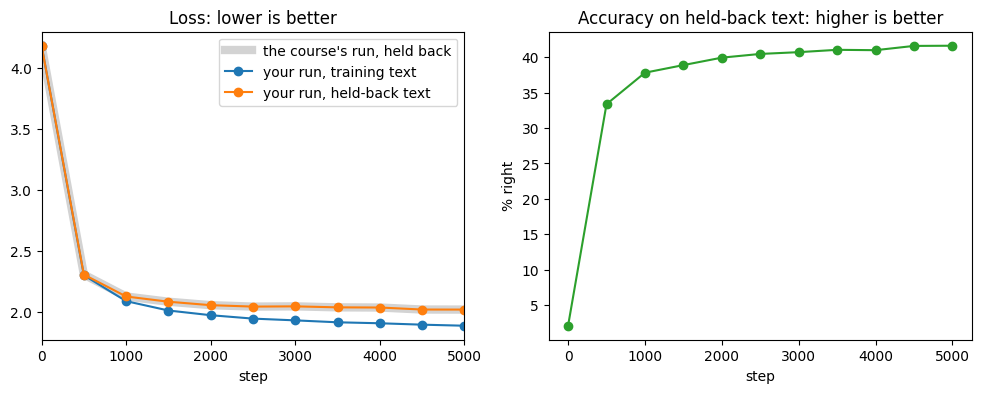

Largest difference from the course's held-back loss over 11 checks: 0.00001


In [17]:
course = json.loads(download("model/prompter-r1-train.json"))["log"]   # the course's checks
course_steps = [c["step"] for c in course]
course_loss = [c["val"] for c in course]

curves, (left, right) = plt.subplots(1, 2, figsize=(12, 4))
left.plot(course_steps, course_loss, color="lightgrey", linewidth=6, label="the course's run, held back")
left.plot(history["step"], history["train_loss"], "o-", label="your run, training text")
left.plot(history["step"], history["held_back_loss"], "o-", label="your run, held-back text")
left.set(title="Loss: lower is better", xlabel="step", xlim=(0, steps))
left.legend()
right.plot(history["step"], [a * 100 for a in history["held_back_accuracy"]], "o-", color="tab:green")
right.set(title="Accuracy on held-back text: higher is better", xlabel="step", ylabel="% right")
plt.show()

biggest = 0
for i in range(len(history["step"])):
    if history["step"][i] == course_steps[i]:                    # the same step in both runs
        biggest = max(biggest, abs(history["held_back_loss"][i] - course_loss[i]))
print(f"Largest difference from the course's held-back loss over {len(history['step'])} checks: {biggest:.5f}")

## 10 · How good is it?

The kept model reads the held-back text from start to end, in back-to-back windows, and is compared with two simple
guessers and the course's full run.

Held-back text, start to end (111,520 next characters): loss 2.016 · accuracy 41.6%

an even guess        loss 4.174 · accuracy 1.5%
counting pairs       loss 2.482
your model           loss 2.016 · accuracy 41.6%
the course's run     loss 1.932 · accuracy 43.9%


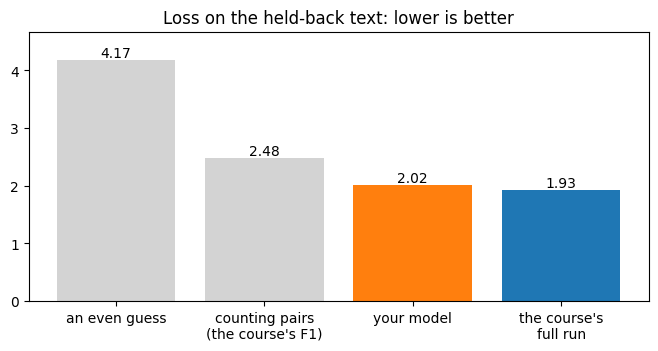

In [18]:
everything = torch.arange(0, len(held_back_ids) - context_length - 1, context_length)   # back-to-back
final_loss, final_accuracy = check(model, held_back_ids, everything)
print(f"Held-back text, start to end ({len(everything) * context_length:,} next characters): "
      f"loss {final_loss:.3f} · accuracy {final_accuracy:.1%}\n")

names = ["an even guess", "counting pairs\n(the course's F1)", "your model", "the course's\nfull run"]
losses = [math.log(vocab_size), 2.482, final_loss, 1.932]     # 2.482 and 1.932: measured in the course
print(f"an even guess        loss {math.log(vocab_size):.3f} · accuracy {1 / vocab_size:.1%}")
print("counting pairs       loss 2.482")
print(f"your model           loss {final_loss:.3f} · accuracy {final_accuracy:.1%}")
print("the course's run     loss 1.932 · accuracy 43.9%")

bars = plt.figure(figsize=(8, 3.5))
plt.bar(names, losses, color=["lightgrey", "lightgrey", "tab:orange", "tab:blue"])
for i in range(len(losses)):
    plt.text(i, losses[i] + 0.05, f"{losses[i]:.2f}", ha="center")
plt.ylim(0, max(losses) + 0.5)
plt.title("Loss on the held-back text: lower is better")
plt.show()

## 11 · Make it write

**Temperature** below 1 makes the text safer; above 1, wilder. The same seed always writes the same text.

In [19]:
samples = ""
for temperature in [0.7, 1.0]:
    sample = write(model, "ROMEO:\n", 240, temperature, seed=7)
    samples += f"--- temperature {temperature} ---\n{sample}\n\n"
print(samples)

--- temperature 0.7 ---
ROMEO:
At 'Take of swill on liftsery cone,
Well, him be my thame the me bead to weet, and is a chall good to that we mald at the old may the of too lave age own with your soon that vress would vild you fair the unt good in to such word.


CAMILR:


--- temperature 1.0 ---
ROMEO:
Dro's mast me:
Eord, liftsery Sair, sempeactract my thyme wather bood Untater, fes is a chall good;
Had ancher'd, Hath graclut to than't forel and goody lorthuman mestn thating;
God; wass lam make.

MYOLK:
Yought in to such I Has done, as s




In [20]:
my_prompt = "JULIET:\n"     # try your own (use only the 65 characters from section 3)
sample = write(model, my_prompt, 300, temperature=0.8, seed=1)
samples += f"--- your prompt, temperature 0.8 ---\n{sample}\n\n"   # saved in section 12
print(sample)

JULIET:
But I ple as to aurse, that
me, by face and with a virt warwick
Then in with poir all gain then she part gof forgoodd:
By corn beats as for thereveds,
He brow, wham, face be is the ellord, let, it be not lovel,
I den and thater is genth hip would I
Shire, thear not, hese their, to to chid breight be


## 12 · Save your model

Everything goes into the `outputs/` folder: in Colab, click the folder icon on the left. Colab also downloads it as a zip.

In [21]:
os.makedirs("outputs", exist_ok=True)
torch.save(model.state_dict(), "outputs/model.pt")                  # the trained numbers
info = {"characters": "".join(chars), "embed_size": embed_size, "num_heads": num_heads,
        "hidden_size": hidden_size, "context_length": context_length, "steps": steps,
        "best_step": best_step, "held_back_loss": final_loss, "held_back_accuracy": final_accuracy}
with open("outputs/model_info.json", "w") as f:
    json.dump(info, f, indent=1)
with open("outputs/history.json", "w") as f:
    json.dump(history, f, indent=1)
with open("outputs/samples.txt", "w") as f:
    f.write(samples)
curves.savefig("outputs/training_curves.png")
bars.savefig("outputs/comparison.png")

reloaded = TinyTransformer().to(device)                              # rebuild it from the file
reloaded.load_state_dict(torch.load("outputs/model.pt", map_location=device, weights_only=True))
same_loss, _ = check(reloaded, held_back_ids, everything)
assert abs(same_loss - final_loss) < 1e-6
print("reloaded outputs/model.pt: same held-back loss ✓\n")
for name in sorted(os.listdir("outputs")):
    print(" ", name)

reloaded outputs/model.pt: same held-back loss ✓

  comparison.png
  history.json
  model.pt
  model_info.json
  samples.txt
  training_curves.png


In [22]:
shutil.make_archive("my-tiny-transformer", "zip", "outputs")
if "google.colab" in sys.modules:                 # in Colab, download the zip
    from google.colab import files
    files.download("my-tiny-transformer.zip")

## 13 · Try next

Change one thing, then **Runtime → Run all**:

- **The full run:** `QUICK = False` in section 7 (about 21 minutes on the course's server; the loss approaches 1.93).
- **A wider model:** `embed_size = 56` and `hidden_size = 112` in section 5.
- **More heads:** `num_heads = 4` (it must divide `embed_size`).
- **Two blocks:** in `TinyTransformer`, add `self.block2 = Block()` and `x = self.block2(x)`.
- **Your own text:** upload a file, then in section 2 `text = open("my_text.txt").read()`. Change the prompts in sections 6
  and 11 to use only its characters.

After a change, your curve leaves the course's grey line. That is your experiment.